# Settings

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import scipy as sc
import scipy.stats as stats
import astropy.cosmology as ac
from matplotlib.patches import Ellipse
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numdifftools as nd
import pandas as pd
import sys
import astropy.constants as cst
import random
from matplotlib.patches import Patch
import zeus
from chainconsumer import ChainConsumer
from tqdm import tqdm
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from astropy.io import fits
from tqdm.notebook import tqdm
from IPython.display import display, Markdown, Math

import astropy.units as u
from scipy.integrate import quad

from sklearn.linear_model import LinearRegression

In [2]:
import fisher_matrix_analysis as fma
import basket as ba
import optimisation_functions as opt
import optimisation_functions_jax as opt_jx

/home/cl-a-millard/venvs/jupyter/lib/python3.14/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


In [3]:
# define cosmological parameters
H0_fid=73
Mb_fid=-19.3
c=float(np.array(cst.c.to('km/s')))


#for flat LCDM, according to Planck 2018 (TT,TE,EE+lowE+lensing)
Om0_fLCDM = 0.3153
Ode0_fLCDM = 1-Om0_fLCDM

#for LCDM
Om0_kLCDM, Ode0_kLCDM = 0.3153, 0.6
Ok0_kLCDM = 1-Om0_kLCDM-Ode0_kLCDM

#for flat wCDM
Om0_fwCDM, w0_fwCDM = 0.3153, -1.029

#for k-wCDM
Om0_kwCDM, Ode0_kwCDM, w0_kwCDM =  0.3153, 0.6, -1.029

#for flat CPL
Om0_fCPL, w0_fCPL, wa_fCPL = 0.3153, -1.029, 0.21

#for CPL
Om0_kCPL, Ode0_kCPL, w0_kCPL, wa_kCPL = 0.3153, 0.6, -1.029, 0.21

#for PEDE
Om0_PEDE, Ode0_PEDE = 0.3153, 0.6
Ok0_PEDE=1-Om0_PEDE-Ode0_PEDE

fiducial_fLCDM  = [Om0_fLCDM,Mb_fid]

fiducial_kLCDM = [Om0_kLCDM, Ode0_kLCDM, Mb_fid]


fiducial_fwCDM = [Om0_fwCDM, w0_fwCDM, Mb_fid]

fiducial_kwCDM = [Om0_kwCDM, Ode0_kwCDM, w0_kwCDM,Mb_fid]

fiducial_fCPL=[Om0_fCPL,w0_fCPL,wa_fCPL,Mb_fid]
 
# fiducial cosmologie
#LCDM
cosmo_fLCDM = ac.FlatLambdaCDM(H0=H0_fid,Om0=Om0_fLCDM)
cosmo_kLCDM = ac.LambdaCDM(H0=H0_fid,Om0=Om0_fLCDM,Ode0=Ode0_fLCDM)

#wCDM
cosmo_fwCDM = ac.FlatwCDM(H0=H0_fid,Om0=Om0_fLCDM,w0=w0_fwCDM)
cosmo_kwCDM = ac.wCDM(H0=H0_fid,Om0=Om0_kwCDM,Ode0=Ode0_kwCDM,w0=w0_kwCDM)

#CPL
cosmo_fCPL=ac.Flatw0waCDM(H0=H0_fid,Om0=Om0_fCPL,w0=w0_fCPL,wa=wa_fCPL)

# Roman data

In [4]:
# Roman data

roman = pd.read_csv('roman_data/mock_roman.csv', sep=';')
z_roman = roman.z.values
dist_roman = roman.Nstar.values
#dist_roman = np.full_like(np.array(z_roman),200) # fake flat distribution
cov = fits.getdata("roman_data/roman_cov.fits")

# last row is the redshifts -> no it is the first one actually
Cov_roman = cov[1:, :]  
II = np.eye(Cov_roman.shape[0])
Cov_inv_roman = np.linalg.solve(Cov_roman, II)
sigma_roman = np.sqrt(np.diag(Cov_roman))

# define bin edges
edges_mid = 0.5 * (z_roman[1:] + z_roman[:-1])
# first and last edges
first_edge = z_roman[0] - (edges_mid[0] - z_roman[0])
last_edge  = z_roman[-1] + (z_roman[-1] - edges_mid[-1])

# combine
z_edges = np.concatenate([[first_edge], edges_mid, [last_edge]])

In [5]:
upper_bound = np.load('SNIa_count.npz')
NIa_tot = upper_bound['NIa_tot']
lsst_SNIa = np.zeros_like(z_roman)
lsst_SNIa[0] = 801 # 800 SNIa at z<0.09

# bon clairement le  3600 est overestimated ou déjà enlevée
# for i in range(1,9):
#     lsst_SNIa[i] = 350 # 3600-800 SNIa at z>0.5 equally divided between the 8 bins

dist_roman_without_lsst = np.copy(dist_roman) - lsst_SNIa
dist_roman_without_lsst

array([ 10.,  24.,  53.,  79., 106., 146., 189., 233., 266., 313., 375.,
       424., 471., 539., 563., 608., 629., 660., 700., 670., 654., 659.,
       650., 612., 556., 516., 504., 436., 409., 374., 331., 289., 270.,
       223., 175., 161., 151., 132., 110.,  90.,  78.,  82.,  69.,  51.,
        59.,  45.,  44.,  32.,  22.,  20.,  11.,  10.,  11.,   9.,   8.,
         4.,   3.,   3.,   4.])

In [6]:
off_diagonal = Cov_roman-np.diag(np.diag(Cov_roman))
Cov_roman_sys = off_diagonal.copy()

n = off_diagonal.shape[0]

for i in range(n):
    # only diagonal elements
    # (since matrix is square, i == j)
    
    # define neighborhood
    i_min = max(i - 1, 0)
    i_max = min(i + 2, n)

    submatrix = off_diagonal[i_min:i_max, i_min:i_max]

    # build global indices
    rows, cols = np.indices(submatrix.shape)
    global_rows = rows + i_min
    global_cols = cols + i_min

    # keep only OFF-diagonal elements (global condition)
    mask = global_rows != global_cols
    values = submatrix[mask]

    Cov_roman_sys[i, i] = values.mean()

Cov_roman_stat = Cov_roman-Cov_roman_sys

fma.is_positive_definite(Cov_roman_stat), fma.is_positive_definite(Cov_roman)

(True, True)

In [7]:
# roman cost
tt = ba.T_ngrt(z_roman)
T0 = (dist_roman*tt).sum()
T0

np.float64(79893117.41864456)

Slope (Coefficient): 3198.5350250377446
Y-Intercept: 0.0


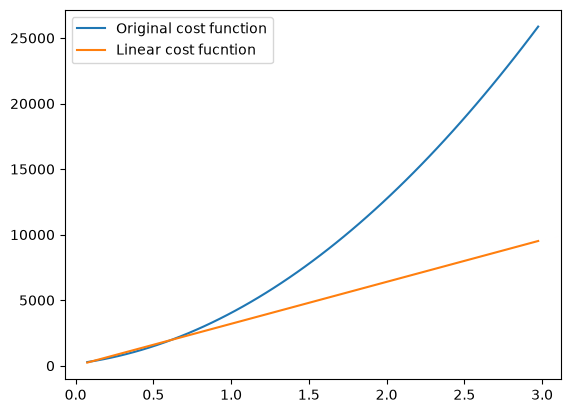

In [8]:
# Sample data: 2D array for features (X), 1D array for target (y)
XX = z_roman[:15].reshape(-1,1)
YY = tt[:15]


# add coordinate [0,0]
XX = np.vstack([np.array([0]), XX])
YY = np.hstack([np.array([0]), YY])

# affine regression
model = LinearRegression(fit_intercept=False)
model.fit(XX, YY)

slope = model.coef_[0]
intercept = model.intercept_

# Results
print(f"Slope (Coefficient): {slope}")
print(f"Y-Intercept: {intercept}")

tt_linear = slope * z_roman + intercept

upper_bound_linear = np.load('SNIa_count_linear_cost.npz')
NIa_tot_linear = upper_bound_linear['NIa_tot']

plt.plot(z_roman, tt, label="Original cost function")
plt.plot(z_roman, tt_linear, label="Linear cost fucntion")
plt.legend()
plt.show()

# Roman Fisher Analysis

In [9]:
cosmo = cosmo_fCPL
cosmo_name = 'fCPL'
fiducial_cosmo = fiducial_fCPL

H0 = ac.WMAP9.H0

num_params=len(fiducial_cosmo)
h = np.array([
            1e-3,   # Om0
            1e-2,   # w0
            5e-2,   # wa
            1e-3    # Mb
        ])

FF = fma.fisher_matrix_observable(fiducial_cosmo,Cov_inv_roman,z_roman,cosmo_name,H0)
II = np.eye(FF.shape[0])
CC_full = np.linalg.solve(FF, II)
CC = fma.marginalize_fisher_matrix(FF, ('w0','wa'), ['Om0', 'w0', 'wa', 'Mb'])
AA = fma.ellipse_parameters(CC, 0.32)[3] #area
FOM = 1/AA

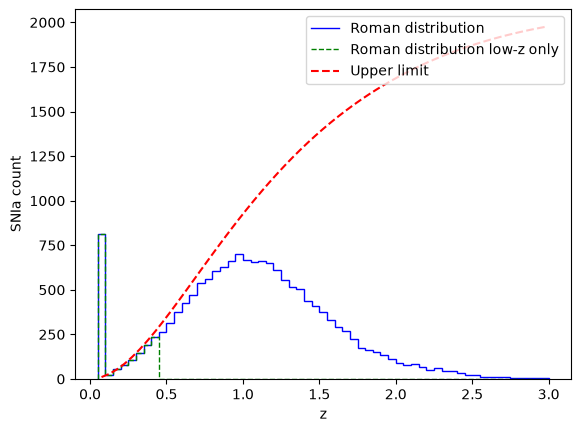

In [10]:
# fisher analysis of roman distribution without high redshift data

lowz_roman = np.copy(dist_roman)
lowz_roman[8:]=1 #otherwise, div by zero in build_covariance

# plot
plt.stairs(dist_roman, z_edges, label='Roman distribution', color='blue')
plt.stairs(lowz_roman, z_edges, label="Roman distribution low-z only", color="green", ls='--')
plt.plot(z_roman, NIa_tot, label='Upper limit', color='red', ls='--')
plt.xlabel("z")
plt.ylabel("SNIa count")
plt.legend(loc='upper right')
plt.show()

In [11]:
Cov_lowz = opt.build_covariance(lowz_roman, dist_roman, Cov_roman_stat, Cov_roman_sys)
Cov_inv_lowz = np.linalg.solve(Cov_lowz, np.eye(Cov_lowz.shape[0]))

FF_lowz = fma.fisher_matrix_observable(fiducial_cosmo,Cov_inv_lowz,z_roman,cosmo_name,H0)
CC_full_lowz = np.linalg.solve(FF_lowz, II)
CC_lowz = fma.marginalize_fisher_matrix(FF_lowz, ('w0','wa'), ['Om0', 'w0', 'wa', 'Mb'])
AA_lowz = fma.ellipse_parameters(CC_lowz, 0.32)[3] #area
FOM_lowz = 1/AA_lowz

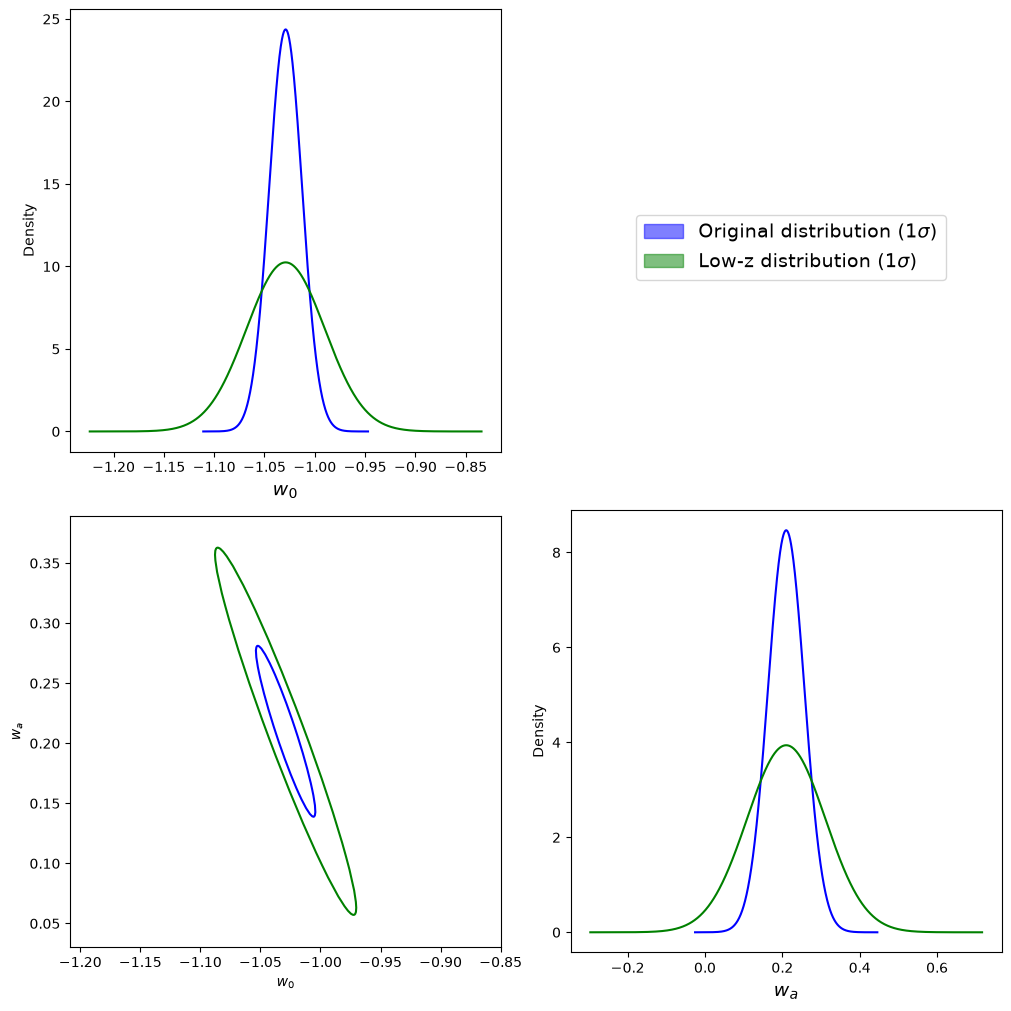

In [12]:
param_names = ['w0', 'wa']
param_labels = [r'$w_0$', r'$w_a$']
param_to_plot = ['w0', 'wa']
fiducial_param = [w0_fCPL, wa_fCPL]


fig, _, axs_2d, axs_1d, param_indices = fma.create_fisher_plot(
    param_names, param_to_plot, param_labels, figsize=10
)
# original fisher matrix
fma.add_fisher_to_plot(
        FF,
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='blue',
        filled=False,
        param_labels=param_labels
    )

fma.add_fisher_to_plot(
        FF_lowz,
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='green',
        filled=False,
        param_labels=param_labels
    )


# Manually add a custom legend for confidence levels and datasets
legend_elements = [
    Patch(facecolor='blue', edgecolor='blue', alpha=0.5, label=r'Original distribution (1$\sigma$)'),
    Patch(facecolor='green', edgecolor='green', alpha=0.5, label=r'Low-z distribution (1$\sigma$)')#,
    # Patch(facecolor='orange', edgecolor='orange', alpha=0.5, label=r'First iteration (1$\sigma$)')
    ]

fig.legend(handles=legend_elements,bbox_to_anchor=(0.95, 0.8), fontsize=14)
#plt.savefig('figures/ellispes_comparison_roman_100')
# Show the final overlaid plot
plt.show()

# Fake Roman distribution

In [13]:
fake_roman = opt.fake_roman_distribution(z_roman, tt_linear, NIa_tot_linear, T0)

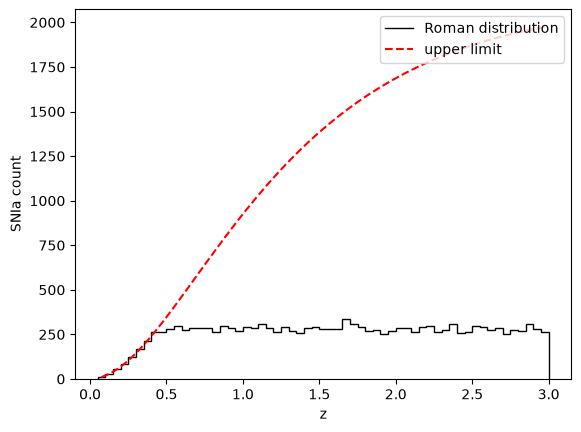

In [14]:
# plot
plt.stairs(fake_roman, z_edges, label="Roman distribution", color="black")
plt.plot(z_roman, NIa_tot, label='upper limit', color='red', ls='--')
plt.xlabel("z")
plt.ylabel("SNIa count")
plt.legend(loc='upper right')
plt.show()

In [15]:
Cov_fake = opt.build_covariance(fake_roman, dist_roman, Cov_roman_stat, Cov_roman_sys)
Cov_inv_fake = np.linalg.solve(Cov_fake, np.eye(Cov_fake.shape[0]))

FF_fake = fma.fisher_matrix_observable(fiducial_cosmo,Cov_inv_fake,z_roman,cosmo_name,H0)
CC_full_fake = np.linalg.solve(FF_fake, np.eye(FF_fake.shape[0]))
CC_fake = fma.marginalize_fisher_matrix(FF_fake, ('w0','wa'), ['Om0', 'w0', 'wa', 'Mb'])
AA_fake = fma.ellipse_parameters(CC_fake, 0.32)[3] #area
FOM_fake = 1/AA_fake

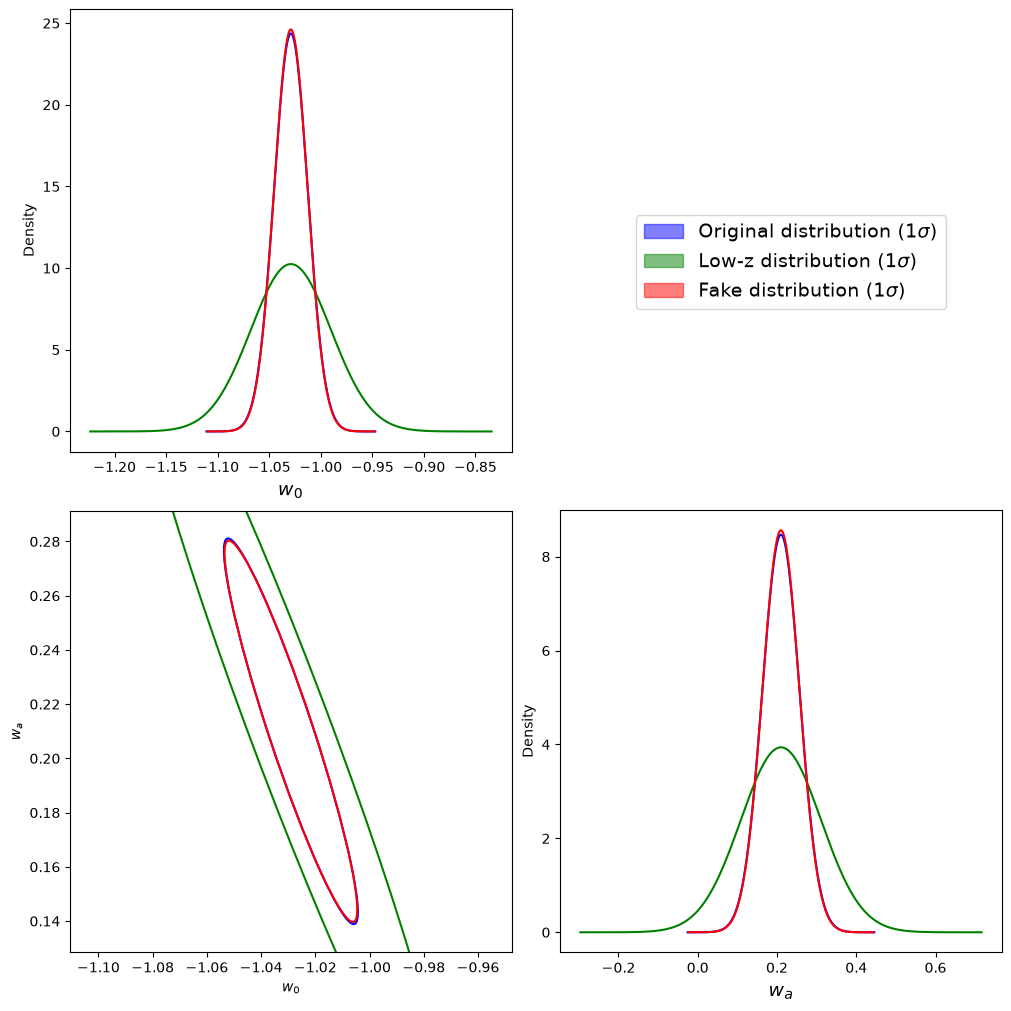

In [16]:
fig, _, axs_2d, axs_1d, param_indices = fma.create_fisher_plot(
    param_names, param_to_plot, param_labels, figsize=10
)
# original fisher matrix
fma.add_fisher_to_plot(
        FF,
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='blue',
        filled=False,
        param_labels=param_labels
    )

fma.add_fisher_to_plot(
        FF_lowz,
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='green',
        filled=False,
        param_labels=param_labels
    )

fma.add_fisher_to_plot(
        FF_fake,
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='red',
        filled=False,
        param_labels=param_labels
    )


# Manually add a custom legend for confidence levels and datasets
legend_elements = [
    Patch(facecolor='blue', edgecolor='blue', alpha=0.5, label=r'Original distribution (1$\sigma$)'),
    Patch(facecolor='green', edgecolor='green', alpha=0.5, label=r'Low-z distribution (1$\sigma$)'),
    Patch(facecolor='red', edgecolor='red', alpha=0.5, label=r'Fake distribution (1$\sigma$)')
    ]

fig.legend(handles=legend_elements,bbox_to_anchor=(0.95, 0.8), fontsize=14)
#plt.savefig('figures/ellispes_comparison_roman_100')
# Show the final overlaid plot
plt.show()

In [17]:
def altered_roman_distribution(redshift_bin, cost, upper_limit, t_tot, i_cut,  dist_roman, seed=26):
    """Generate a distribution of SNIa respecting the total observing time t_tot (in s)
    
    Parameters:
    redshift_bin (np.array): array of redshift bins
    cost (float): cost per SNIa in SNIa
    upper_limit (float): upper limit on the number of SNIa in each bin
    t_tot (float): total observing time in s
    i_cut (int): index at which we start to alter the distribution
    dist_roman (np.array): original Roman distribution
    
    Return:
    fake_dist (np.array): array of SNIa"""

    r = np.random.RandomState(seed)


    # initialize a time tracker and the fake_distribution array
    fake_dist = np.copy(dist_roman)
    fake_dist[i_cut:] = 1
    time_tracker = (fake_dist * cost).sum()

    while time_tracker <= t_tot:

        # bin i can receive a SNIa if its it is bigger than i_cut, time_cost doesn't make the time_tracker exceed t_tot, 
        # and if it doesn't make the number of SNIa in the bin exceed the upper limit
        valid_bins = [ i for i in range(len(redshift_bin)) if i >= i_cut and time_tracker + cost[i] <= t_tot and fake_dist[i] + 1 <= upper_limit[i] ]

        if valid_bins==[]:
            break

        else:
            # randomly select a redshfit bin
            random_bin = r.randint(len(valid_bins))

            # add one SNIa in the corresponding bin of fake_dist, and the adequate cost to the time_tracker
            fake_dist[valid_bins[random_bin]] += 1
            time_tracker += cost[valid_bins[random_bin]]

    return fake_dist

In [18]:
cut_at = 19
altered_dist1 = altered_roman_distribution(z_roman, tt_linear, NIa_tot_linear, T0, cut_at, dist_roman,seed=11)
altered_dist2 = altered_roman_distribution(z_roman, tt_linear, NIa_tot_linear, T0, cut_at, dist_roman,seed=22)
altered_dist3 = altered_roman_distribution(z_roman, tt_linear, NIa_tot_linear, T0, cut_at, dist_roman,seed=33)

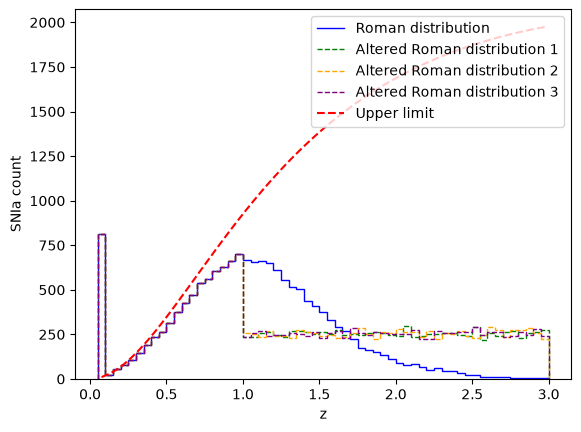

In [19]:


# plot
plt.stairs(dist_roman, z_edges, label='Roman distribution', color='blue')
plt.stairs(altered_dist1, z_edges, label="Altered Roman distribution 1", color="green", ls='--')
plt.stairs(altered_dist2, z_edges, label="Altered Roman distribution 2", color="orange", ls='--')
plt.stairs(altered_dist3, z_edges, label="Altered Roman distribution 3", color="purple", ls='--')
plt.plot(z_roman, NIa_tot, label='Upper limit', color='red', ls='--')
plt.xlabel("z")
plt.ylabel("SNIa count")
plt.legend(loc='upper right')
plt.show()

In [20]:
Cov_altered1= opt.build_covariance(altered_dist1, dist_roman, Cov_roman_stat, Cov_roman_sys)
Cov_inv_altered1= np.linalg.solve(Cov_altered1, np.eye(Cov_altered1.shape[0]))

FF_altered1= fma.fisher_matrix_observable(fiducial_cosmo,Cov_inv_altered1,z_roman,cosmo_name,H0)
CC_full_altered1= np.linalg.solve(FF_altered1, np.eye(FF_altered1.shape[0]))
CC_altered1= fma.marginalize_fisher_matrix(FF_altered1, ('w0','wa'), ['Om0', 'w0', 'wa', 'Mb'])
AA_altered1= fma.ellipse_parameters(CC_altered1, 0.32)[3] #area
FOM_altered1= 1/AA_altered1

In [21]:
Cov_altered2= opt.build_covariance(altered_dist2, dist_roman, Cov_roman_stat, Cov_roman_sys)
Cov_inv_altered2= np.linalg.solve(Cov_altered2, np.eye(Cov_altered2.shape[0]))

FF_altered2= fma.fisher_matrix_observable(fiducial_cosmo,Cov_inv_altered2,z_roman,cosmo_name,H0)
CC_full_altered2= np.linalg.solve(FF_altered2, II)
CC_altered2= fma.marginalize_fisher_matrix(FF_altered2, ('w0','wa'), ['Om0', 'w0', 'wa', 'Mb'])
AA_altered2= fma.ellipse_parameters(CC_altered2, 0.32)[3] #area
FOM_altered2= 1/AA_altered2

In [22]:
Cov_altered3= opt.build_covariance(altered_dist3, dist_roman, Cov_roman_stat, Cov_roman_sys)
Cov_inv_altered3= np.linalg.solve(Cov_altered3, np.eye(Cov_altered3.shape[0]))

FF_altered3= fma.fisher_matrix_observable(fiducial_cosmo,Cov_inv_altered3,z_roman,cosmo_name,H0)
CC_full_altered3= np.linalg.solve(FF_altered3, np.eye(FF_altered3.shape[0]))
CC_altered3= fma.marginalize_fisher_matrix(FF_altered3, ('w0','wa'), ['Om0', 'w0', 'wa', 'Mb'])
AA_altered3= fma.ellipse_parameters(CC_altered3, 0.32)[3] #area
FOM_altered3= 1/AA_altered3

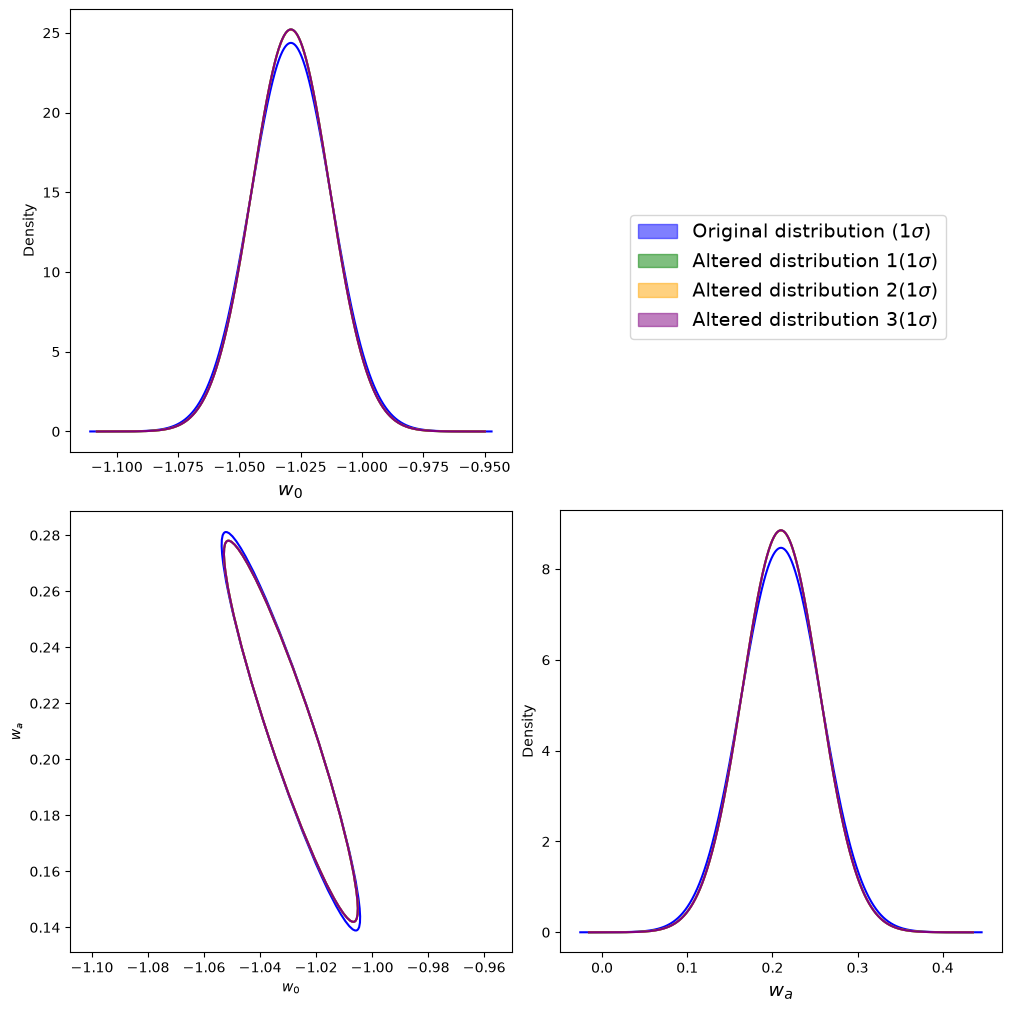

In [23]:
fig, _, axs_2d, axs_1d, param_indices = fma.create_fisher_plot(
    param_names, param_to_plot, param_labels, figsize=10
)
# original fisher matrix
fma.add_fisher_to_plot(
        FF,
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='blue',
        filled=False,
        param_labels=param_labels
    )

fma.add_fisher_to_plot(
        FF_altered1,
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='green',
        filled=False,
        param_labels=param_labels
    )

fma.add_fisher_to_plot(
        FF_altered2,
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='orange',
        filled=False,
        param_labels=param_labels
    )

fma.add_fisher_to_plot(
        FF_altered3,
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='purple',
        filled=False,
        param_labels=param_labels
    )


# Manually add a custom legend for confidence levels and datasets
legend_elements = [
    Patch(facecolor='blue', edgecolor='blue', alpha=0.5, label=r'Original distribution (1$\sigma$)'),
    Patch(facecolor='green', edgecolor='green', alpha=0.5, label=r'Altered distribution 1(1$\sigma$)'),
    Patch(facecolor='orange', edgecolor='orange', alpha=0.5, label=r'Altered distribution 2(1$\sigma$)'),
    Patch(facecolor='purple', edgecolor='purple', alpha=0.5, label=r'Altered distribution 3(1$\sigma$)')
    ]

fig.legend(handles=legend_elements,bbox_to_anchor=(0.95, 0.8), fontsize=14)

plt.show()

In [24]:
tt

array([  280.10751685,   377.06861279,   486.10874409,   607.22791076,
         740.42611279,   885.70335018,  1043.05962294,  1212.49493107,
        1394.00927455,  1587.60265341,  1793.27506762,  2011.0265172 ,
        2240.85700214,  2482.76652245,  2736.75507813,  3002.82266916,
        3280.96929556,  3571.19495733,  3873.49965446,  4187.88338695,
        4514.34615481,  4852.88795803,  5203.50879661,  5566.20867056,
        5940.98757988,  6327.84552455,  6726.7825046 ,  7137.79852   ,
        7560.89357077,  7996.06765691,  8443.32077841,  8902.65293527,
        9374.06412749,  9857.55435509, 10353.12361804, 10860.77191636,
       11380.49925004, 11912.30561909, 12456.1910235 , 13012.15546328,
       13580.19893842, 14160.32144892, 14752.52299479, 15356.80357602,
       15973.16319262, 16601.60184458, 17242.11953191, 17894.7162546 ,
       18559.39201265, 19236.14680607, 19924.98063485, 20625.89349899,
       21338.8853985 , 22063.95633338, 22801.10630362, 23550.33530922,
      

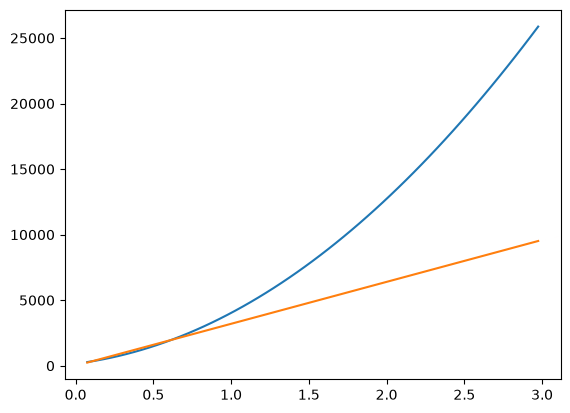

In [25]:
plt.plot(z_roman,tt)
plt.plot(z_roman, tt_linear)

In [26]:
def until_full_roman_distribution(redshift_bin, cost, upper_limit, t_tot):
    """Generate a distribution of SNIa respecting the total observing time t_tot (in s)
    
    Parameters:
    redshift_bin (np.array): array of redshift bins
    cost (float): cost per SNIa in SNIa
    upper_limit (float): upper limit on the number of SNIa in each bin
    t_tot (float): total observing time in s
    
    Return:
    fake_dist (np.array): array of SNIa"""


    # initialize a time tracker and the fake_distribution array
    fake_dist = np.ones_like(redshift_bin)
    time_tracker = (fake_dist * cost).sum()

    for i in range(len(redshift_bin)):
        while time_tracker + cost[i] <= t_tot and fake_dist[i] + 1 <= upper_limit[i]:
            fake_dist[i] += 1
            time_tracker += cost[i]

    fake_dist[0] += 800 #LSST SNIa

    return fake_dist

In [27]:
full_dist = until_full_roman_distribution(z_roman, tt, NIa_tot, T0)

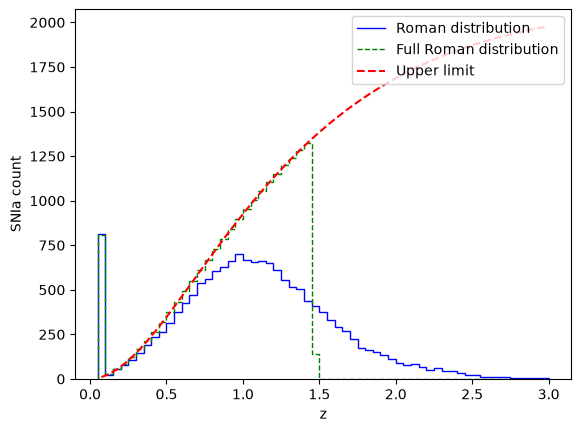

In [28]:


# plot
plt.stairs(dist_roman, z_edges, label='Roman distribution', color='blue')
plt.stairs(full_dist, z_edges, label="Full Roman distribution", color="green", ls='--')
plt.plot(z_roman, NIa_tot, label='Upper limit', color='red', ls='--')
plt.xlabel("z")
plt.ylabel("SNIa count")
plt.legend(loc='upper right')
plt.show()

In [29]:
Cov_full= opt.build_covariance(full_dist, dist_roman, Cov_roman_stat, Cov_roman_sys)
Cov_inv_full= np.linalg.solve(Cov_full, np.eye(Cov_full.shape[0]))

FF_full= fma.fisher_matrix_observable(fiducial_cosmo,Cov_inv_full,z_roman,cosmo_name,H0)
CC_full= np.linalg.solve(FF_full, np.eye(FF_full.shape[0]))
CC_full= fma.marginalize_fisher_matrix(FF_full, ('w0','wa'), ['Om0', 'w0', 'wa', 'Mb'])
AA_full= fma.ellipse_parameters(CC_full, 0.32)[3] #area
FOM_full= 1/AA_full

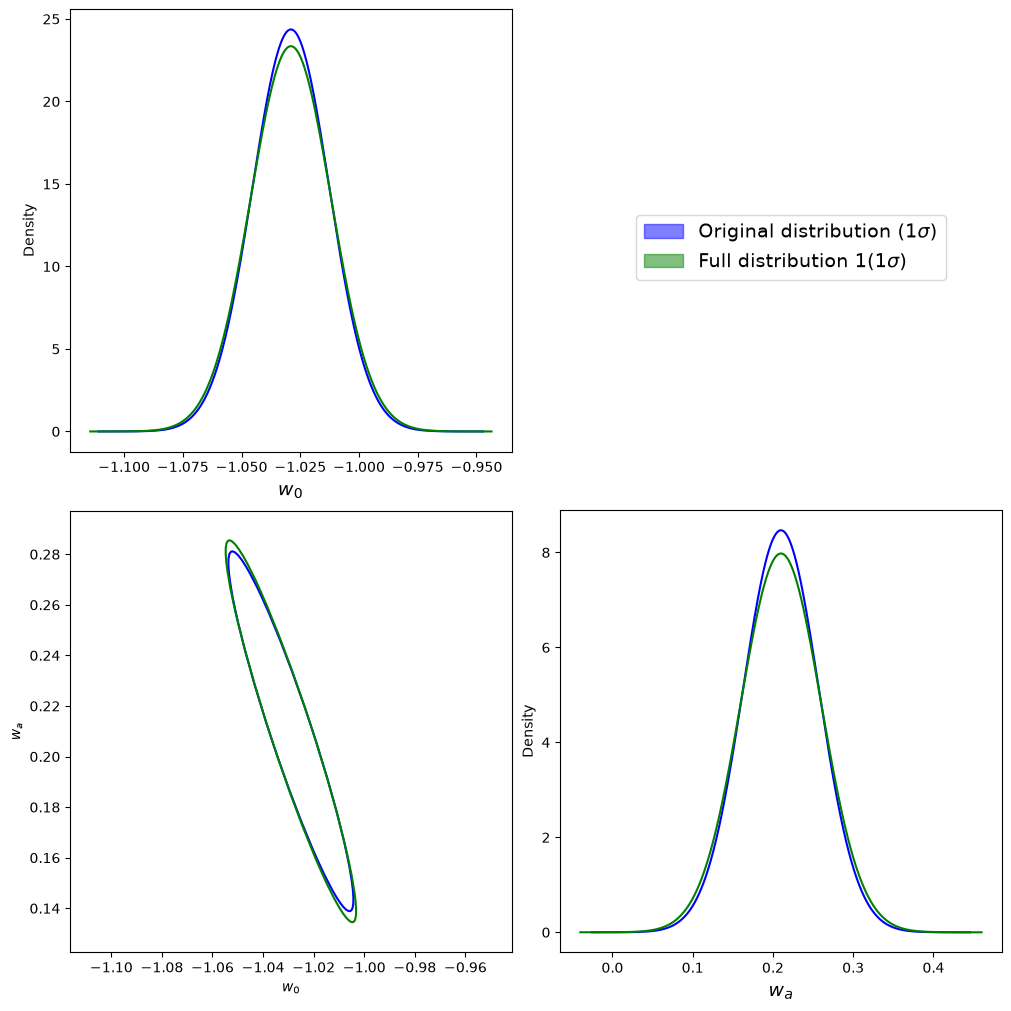

In [30]:
fig, _, axs_2d, axs_1d, param_indices = fma.create_fisher_plot(
    param_names, param_to_plot, param_labels, figsize=10
)
# original fisher matrix
fma.add_fisher_to_plot(
        FF,
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='blue',
        filled=False,
        param_labels=param_labels
    )

fma.add_fisher_to_plot(
        FF_full,
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='green',
        filled=False,
        param_labels=param_labels
    )


# Manually add a custom legend for confidence levels and datasets
legend_elements = [
    Patch(facecolor='blue', edgecolor='blue', alpha=0.5, label=r'Original distribution (1$\sigma$)'),
    Patch(facecolor='green', edgecolor='green', alpha=0.5, label=r'Full distribution 1(1$\sigma$)')
    ]

fig.legend(handles=legend_elements,bbox_to_anchor=(0.95, 0.8), fontsize=14)

plt.show()

# 1st iteration mystery

In [31]:
import jax
import jax.numpy as jnp
import jax_cosmo as jc
jax.config.update("jax_enable_x64", True)
from jax import lax

In [32]:
import jax_optimizer as opt_jax

In [33]:
FOM

np.float64(5.716459837990183)

In [34]:
dFOM_pbin = np.zeros_like(z_roman, dtype=float)

for ii in range(len(dist_roman)):

    dist_perturbed = np.array(dist_roman, copy=True)
    dist_perturbed[ii] += 1.0

    Covi = opt_jax.build_covariance(
        dist_perturbed,
        dist_roman,
        Cov_roman_stat,
        Cov_roman_sys,
    )

    Cov_invi = np.linalg.solve(
        np.asarray(Covi),
        np.eye(len(dist_roman)),
    )

    FFi = opt_jax.fisher_matrix_observable(
        fiducial_cosmo,
        Cov_invi,
        z_roman,
        H0,
    )

    CCi = opt_jax.marginalize_fisher_matrix(
        FFi,
        ('w0', 'wa'),
        ['Om0', 'w0', 'wa', 'Mb'],
    )

    AAi = opt_jax.ellipse_parameters(
        CCi,
        0.32,
    )[3]

    FOMi = 1.0 / AAi

    dFOM_pbin[ii] = (FOMi - FOM) / tt[ii]

In [35]:
dFOM_pbin

array([ 1.47420931e-06,  3.95742371e-05,  1.08664680e-05,  3.86938069e-06,
        1.52875864e-06,  7.95565650e-07,  5.38773184e-07,  4.17904280e-07,
        3.03649674e-07,  2.15866877e-07,  1.43511781e-07,  9.03201266e-08,
        5.35630733e-08,  3.13193927e-08,  2.00539003e-08,  1.59970597e-08,
        1.50415094e-08,  1.57299511e-08,  1.67751894e-08,  1.79016691e-08,
        1.16597572e-08,  1.01626889e-08,  8.42186469e-09,  6.29678493e-09,
        3.68926414e-09,  1.85758783e-09,  3.26295191e-10, -7.23102821e-10,
       -7.89763605e-10, -5.68715235e-12,  1.67628882e-09,  4.74879163e-09,
        8.12485650e-09,  1.29609598e-08,  1.96622067e-08,  2.41134405e-08,
        2.92753299e-08,  3.12224360e-08,  3.60677226e-08,  4.32661106e-08,
        4.72063477e-08,  5.02962815e-08,  5.55473334e-08,  6.33289372e-08,
        6.78338398e-08,  6.87114085e-08,  7.57448858e-08,  7.25939480e-08,
        7.59635832e-08,  7.46721932e-08,  5.90317527e-08,  5.34641226e-08,
        5.27613312e-08,  

In [36]:
nb_iter = 1

results = opt_jax.optimize_bins_again_jax(
    nb_iter=nb_iter,
    perturbation=1.0,
    dist_roman=dist_roman,
    Cov_roman=Cov_roman,
    Cov_roman_stat=Cov_roman_stat,
    Cov_roman_sys=Cov_roman_sys,
    FOM=FOM,
    H0=H0,
    z_roman=z_roman,
    tt=tt,
    fiducial_cosmo=fiducial_cosmo,
    param_tuple=("w0", "wa"),
    param_names=("Om0", "w0", "wa", "Mb"),
    NIa_tot=NIa_tot,
    use_marginalization=True,
    verbose=True,
)

Optimizing bins:   0%|          | 0/1 [00:00<?, ?iter/s]

In [37]:
optimized_dist       =  results["optimized_dist"]

track_distribution   = results["track_distribution"]
track_delta_n        = results["track_delta_n"]
track_Cov            = results["track_Cov"]
track_dFOM           = results["track_dFOM"]
track_dFOM_triche    = results["track_dFOM_triche"]
track_kk             = results["track_kk"]
track_FF             = results["track_FF"]
track_ellipse        = results["track_ellipse"]

In [38]:
track_dFOM

Array([[ 1.47420931e-06,  3.95742371e-05,  1.08664680e-05,
         3.86938069e-06,  1.52875864e-06,  7.95565650e-07,
         5.38773184e-07,  4.17904280e-07,  3.03649674e-07,
         2.15866877e-07,  1.43511780e-07,  9.03201267e-08,
         5.35630733e-08,  3.13193927e-08,  2.00539003e-08,
         1.59970598e-08,  1.50415094e-08,  1.57299511e-08,
         1.67751895e-08,  1.79016691e-08,  1.16597572e-08,
         1.01626889e-08,  8.42186471e-09,  6.29678495e-09,
         3.68926417e-09,  1.85758784e-09,  3.26295196e-10,
        -7.23102808e-10, -7.89763588e-10, -5.68714036e-12,
         1.67628884e-09,  4.74879163e-09,  8.12485650e-09,
         1.29609598e-08,  1.96622067e-08,  2.41134405e-08,
         2.92753299e-08,  3.12224360e-08,  3.60677226e-08,
         4.32661106e-08,  4.72063477e-08,  5.02962815e-08,
         5.55473334e-08,  6.33289372e-08,  6.78338398e-08,
         6.87114086e-08,  7.57448858e-08,  7.25939480e-08,
         7.59635832e-08,  7.46721932e-08,  5.90317527e-0

In [39]:
dFOM_jax = np.asarray(track_dFOM[0])

print("max abs difference:",
      np.max(np.abs(dFOM_jax - dFOM_pbin)))

print("max relative difference:",
      np.max(
          np.abs(dFOM_jax - dFOM_pbin)
          / np.maximum(np.abs(dFOM_pbin), 1e-30)
      ))

print(
    np.column_stack([
        np.arange(len(z_roman)),
        dFOM_jax,
        dFOM_pbin,
        dFOM_jax - dFOM_pbin,
    ])
)


max abs difference: 4.91481550281888e-16
max relative difference: 2.1093694381528907e-06
[[ 0.00000000e+00  1.47420931e-06  1.47420931e-06  4.91481550e-16]
 [ 1.00000000e+00  3.95742371e-05  3.95742371e-05 -2.35542922e-17]
 [ 2.00000000e+00  1.08664680e-05  1.08664680e-05 -1.57133082e-16]
 [ 3.00000000e+00  3.86938069e-06  3.86938069e-06  1.71133690e-16]
 [ 4.00000000e+00  1.52875864e-06  1.52875864e-06  8.15694846e-17]
 [ 5.00000000e+00  7.95565650e-07  7.95565650e-07  4.01117746e-17]
 [ 6.00000000e+00  5.38773184e-07  5.38773184e-07  2.21393237e-17]
 [ 7.00000000e+00  4.17904280e-07  4.17904280e-07  1.25993663e-16]
 [ 8.00000000e+00  3.03649674e-07  3.03649674e-07  8.72881216e-17]
 [ 9.00000000e+00  2.15866877e-07  2.15866877e-07 -2.12589388e-17]
 [ 1.00000000e+01  1.43511780e-07  1.43511781e-07 -6.04244982e-17]
 [ 1.10000000e+01  9.03201267e-08  9.03201266e-08  5.91816494e-17]
 [ 1.20000000e+01  5.35630733e-08  5.35630733e-08  5.19227094e-17]
 [ 1.30000000e+01  3.13193927e-08  3.131